In [1]:
import torch
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision.transforms import v2
from torchvision.models import efficientnet_b0,EfficientNet_B0_Weights,densenet121,DenseNet121_Weights
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import random
import os
import timm
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import roc_auc_score,f1_score, ConfusionMatrixDisplay
import csv
import cv2
from sklearn.manifold import TSNE
import pandas as pd
import seaborn as sns
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GradCAM(torch.nn.Module):
    def __init__(self,model,target_layer):
        super(GradCAM, self).__init__()
        
        # get the pretrained VGG19 network
        self.model = model.eval()
        self.target_layer = target_layer
        
        self.activation = None
        self.gradient = None

        target_layer.register_forward_hook(self.hook_activation)
        target_layer.register_forward_hook(self.hook_gradient)
    
    def hook_activation(self, module, input, output):
        self.activation = output.cpu().detach()

    def hook_gradient(self, module, input,output):
        def save_grad(grad):
            self.gradient = grad.cpu().detach()
        output.register_hook(save_grad)

    def __call__(self, x):
        self.activation = None
        self.gradients = None
        return self.model(x)
    
    # method for the gradient extraction
    def get_activation_gradient(self):
        return self.activation, self.gradient
    
def save_gradcam(model, sample, image, class_int, img_name,image_shape):
    output=model(sample)

    output[:,class_int].backward()

    activation,gradient = model.get_activation_gradient()
    activation,gradient = activation.squeeze(0), gradient.squeeze(0)


    gradient = torch.mean(gradient,dim=[1,2])
    activation=activation*gradient.reshape(-1,1,1)

    heatmap = activation.mean(dim=0)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= torch.max(heatmap)
    heatmap = heatmap.cpu().detach().data.numpy()
    heatmap=cv2.resize(heatmap,(image_shape,image_shape))
    heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)

    cv2.imwrite(img_name,image+0.5*heatmap)

class KONet(torch.nn.Module):

    def __init__(
            self,
            m1_ratio=0.4,
            m2_ratio=0.6,
            m1_dropout=0.1,
            m2_dropout=0.3,
            n_classes=2
    ):
        super().__init__()
        assert m1_ratio+m2_ratio==1
        self.n_classes=n_classes
        self.m1_ratio=m1_ratio #EfficientNet
        self.m2_ratio=m2_ratio #DenseNet
        self.m1_dropout=m1_dropout
        self.m2_dropout=m2_dropout

        self.efficient=efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.efficient.classifier[0]=torch.nn.Dropout(p=self.m1_dropout,inplace=True)
        self.efficient.classifier[-1]=torch.nn.Linear(in_features=1280,out_features=self.n_classes)

        self.dense=densenet121(weights=DenseNet121_Weights.DEFAULT)
        self.dense.classifier=torch.nn.Sequential(torch.nn.Dropout(p=self.m2_dropout,inplace=True),
                                            torch.nn.Linear(in_features=1024,out_features=n_classes),
                                            )

    def forward(self, x):
        m1=self.efficient(x)
        m2=self.dense(x)
        out=self.m1_ratio*m1+self.m2_ratio*m2
        return out


def test(model,dataloader,loss_fn):
    model.eval()
    loss=0
    labels=[]
    probabilities=[]
    for data,label in dataloader:
        with torch.no_grad():
            data , label=data.to(device) , label.to(device)

            output=model(data)
            loss+=loss_fn(output , label)
            prob=output.softmax(dim=1)
            labels.append(label.detach().cpu().numpy())
            probabilities.append(prob.detach().cpu().numpy())

    labels=np.concatenate(labels,axis=0)
    probabilities=np.concatenate(probabilities,axis=0)

    loss=loss/len(dataloader)
    return loss.item(),labels,probabilities


def set_random_seed(seed: int = 2222, deterministic: bool = False):
        random.seed(seed)
        np.random.seed(seed)
        os.environ["PYTHONHASHSEED"] = str(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)  # type: ignore
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = deterministic  # type: ignore


def prep_dataset(path, image_shape=224, augmented_dataset_size=1800,
                 train_split=0.8, valid_split=0.1, test_split=0.1, seed=42):

    non_augment_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32,scale=True),
        v2.Resize((image_shape, image_shape), antialias=True),
        v2.Normalize(mean=[0.5], std=[0.5]),
    ])

    aug_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32,scale=True),
        v2.RandomAffine(degrees=30, shear=30),
        v2.RandomZoomOut(side_range=(1, 1.5)),
        v2.Resize((image_shape, image_shape), antialias=True),
        v2.Normalize(mean=[0.5], std=[0.5]),
    ])

    base_dataset = torchvision.datasets.ImageFolder(path, transform=non_augment_transform)
    augmented_dataset = torchvision.datasets.ImageFolder(path, transform=aug_transform)
    n_samples = len(base_dataset)

    labels = [s[1] for s in base_dataset.samples]
    indices = np.arange(n_samples)

    # split test first
    train_val_idx, test_idx = train_test_split(indices, test_size=test_split, stratify=labels, random_state=seed)

    kf = KFold(n_splits=10, shuffle=True, random_state=seed)
    splits = list(kf.split(train_val_idx))

    fold_datasets=[]
    factor=augmented_dataset_size//len(base_dataset)
    
    for fold, (train_indices, val_indices) in enumerate(splits):
        augmented_train_indices = np.repeat(train_indices, factor)
        train_set = torch.utils.data.Subset(augmented_dataset, augmented_train_indices)
        valid_set = torch.utils.data.Subset(base_dataset, val_indices)
        fold_datasets.append((fold+1,train_set,valid_set))

    test_subset = torch.utils.data.Subset(base_dataset, test_idx)


    return fold_datasets, test_subset

In [23]:
n_classes=2
image_shape=224
augmented_dataset_size=1800
batch_size=32
epochs=20
seed=42
model_name= 'efficient'
script_name = 'train OKD'
results_file = "fold_results.csv"
path="/kaggle/input/datasets/haiderazam/osteoporosis-knee-x-ray-dataset-preprocessed/Osteoporosis Knee X-ray Dataset Preprocessed"
weights_path="/kaggle/input/datasets/haiderazam/okd-weights/train OKD/model"
os.makedirs('model',exist_ok=True)

In [24]:
set_random_seed(seed)

fold_datasets, test_set = prep_dataset(path, image_shape, augmented_dataset_size)

best_acc=0
best_loss=np.inf
best_loss_fold=None
best_fold=None
print('Model: ',model_name)
for fold, train_set, valid_set in fold_datasets:
    print(f"Fold {fold}")
    best_val_loss = np.inf
    best_val_acc = 0
    print(f"Test set size: {len(test_set)}, Validation set size: {len(valid_set)}")
    
    
    valid_dataloader = DataLoader(valid_set, batch_size=batch_size, num_workers=4, pin_memory=True,
                                    persistent_workers=True, shuffle=False)
    
    test_dataloader = DataLoader(test_set, batch_size=batch_size, num_workers=4, pin_memory=True,
                                    persistent_workers=True, shuffle=False)
    
    
    
    if model_name=='efficient':
        model=efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        p=0.1
        model.classifier[0]=torch.nn.Dropout(p=p,inplace=True)
        model.classifier[-1]=torch.nn.Linear(in_features=1280,out_features=n_classes)
    
    elif model_name=='dense':
        model=densenet121(weights=DenseNet121_Weights.DEFAULT)
        p=0.3
        model.classifier=torch.nn.Sequential(torch.nn.Dropout(p=p,inplace=True),
                                            torch.nn.Linear(in_features=1024,out_features=n_classes),
                                            )
    
    elif model_name=='conv_next':
        p=0.3
        model=torchvision.models.convnext_tiny(weights='DEFAULT')
        model.classifier[2]=torch.nn.Sequential(torch.nn.Dropout(p=p,inplace=True),
                                            torch.nn.Linear(in_features=768,out_features=n_classes),
                                            )
    elif model_name=='edgenext':
        model=timm.create_model("edgenext_small.usi_in1k",
                                        pretrained=True, 
                                        features_only=False,
                                        in_chans=3,
                                        num_classes=n_classes,
                                        global_pool='avg'
                                        )
    
    elif model_name=='KONet':
        m1_ratio=0.4
        m2_ratio=0.6
        m1_dropout=0.1
        m2_dropout=0.3
        model=KONet(m1_ratio=m1_ratio,m2_ratio=m2_ratio,m1_dropout=m1_dropout,m2_dropout=m2_dropout,n_classes=n_classes)
    
    elif model_name=='mobilenet':
        model=torchvision.models.mobilenet_v3_small(weights='DEFAULT')
        model.classifier[3]=torch.nn.Linear(in_features=1024,out_features=n_classes)
    
    model.to(device)
    optimizer=torch.optim.AdamW(model.parameters(),lr=0.0000625)
    
    loss_fn=torch.nn.CrossEntropyLoss()
    

    model.load_state_dict(torch.load(f'{weights_path}/{model_name}_fold_{fold}_best_param.pkl'))
    model.eval()
    test_loss, test_labels, test_probabilities = test(model, test_dataloader, loss_fn)
    test_pred_labels = np.argmax(test_probabilities, axis=1)
    test_acc = np.mean(test_pred_labels == test_labels)

    if best_loss>test_loss:
        best_loss=test_loss
        best_loss_fold=fold
        print(f"best loss at {fold}")
    
    if best_acc<test_acc:
        best_acc=test_acc
        best_fold=fold
        best_test_pred=test_pred_labels
        print(f"best accuracy at {fold}")
        test_auc=roc_auc_score(test_labels,test_probabilities[:,1])
        test_f1=f1_score(test_labels,test_pred_labels,average='weighted')

        print(f"Accuracy: {test_acc}")
        print(f"F1-Score: {test_f1}")
        print(f"ROC_AUC: {test_auc}")

        
    print(f"Test set accuracy: {test_acc}")

Model:  efficient
Fold 1
Test set size: 38, Validation set size: 34
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 212MB/s]


best loss at 1
best accuracy at 1
Accuracy: 0.9473684210526315
F1-Score: 0.9473684210526315
ROC_AUC: 0.9750692520775622
Test set accuracy: 0.9473684210526315
Fold 2
Test set size: 38, Validation set size: 34
Test set accuracy: 0.8947368421052632
Fold 3
Test set size: 38, Validation set size: 34
best loss at 3
Test set accuracy: 0.9473684210526315
Fold 4
Test set size: 38, Validation set size: 34
Test set accuracy: 0.8947368421052632
Fold 5
Test set size: 38, Validation set size: 33
Test set accuracy: 0.8947368421052632
Fold 6
Test set size: 38, Validation set size: 33
best loss at 6
Test set accuracy: 0.9210526315789473
Fold 7
Test set size: 38, Validation set size: 33
Test set accuracy: 0.9473684210526315
Fold 8
Test set size: 38, Validation set size: 33
Test set accuracy: 0.868421052631579
Fold 9
Test set size: 38, Validation set size: 33
Test set accuracy: 0.8947368421052632
Fold 10
Test set size: 38, Validation set size: 33
Test set accuracy: 0.9473684210526315


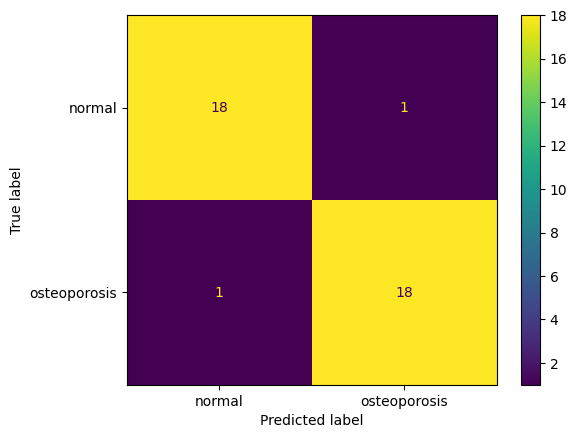

In [25]:
ConfusionMatrixDisplay.from_predictions(test_labels,best_test_pred,
                                        display_labels=['normal','osteoporosis']
                                        )
plt.show()

In [26]:
#GradCAM part
model.load_state_dict(torch.load(f'{weights_path}/{model_name}_fold_{best_fold}_best_param.pkl'))
if model_name=='efficient':
    target_layer = model.features[8][0]
    
elif model_name=='dense':
    target_layer = model.features[-2].denselayer16.conv2

elif 'mobilenet' in model_name:
    target_layer = model.features[-1][0]

elif 'edgenext' in model_name:
    target_layer = model.stages[-1].blocks[-1].convs[0]

gradcam_model=GradCAM(model,target_layer)

normal_sample=test_set.__getitem__(1)[0].unsqueeze(0)
osteoporosis_sample=test_set.__getitem__(2)[0].unsqueeze(0)

normal_sample = normal_sample.to(device)
osteoporosis_sample = osteoporosis_sample.to(device)

normal_image=(normal_sample+1)*127
normal_image=normal_image.to(torch.int64).cpu().numpy()
normal_image=normal_image[0].transpose(1,2,0)
cv2.imwrite('normal_image.jpg',normal_image)

osteoporosis_image=(osteoporosis_sample+1)*127
osteoporosis_image=osteoporosis_image.to(torch.int64).cpu().numpy()
osteoporosis_image=osteoporosis_image[0].transpose(1,2,0)
cv2.imwrite('osteoporosis_image.jpg',osteoporosis_image)

class_int=0
img_name = f"normal_heatmap_{model_name}.jpg"
save_gradcam(gradcam_model,normal_sample,normal_image,class_int,img_name,image_shape)

class_int=1
img_name = f"osteoporosis_heatmap_{model_name}.jpg"
save_gradcam(gradcam_model,osteoporosis_sample,osteoporosis_image,class_int,img_name,image_shape)

100%|██████████| 38/38 [00:00<00:00, 54.62it/s]


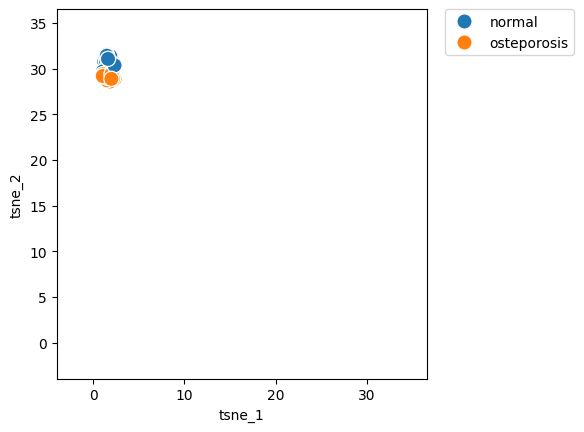

In [41]:
#tSNE part


model.load_state_dict(torch.load(f'{weights_path}/{model_name}_fold_{best_fold}_best_param.pkl'))
model.eval()

if model_name=='efficient':
    num_features=1280
    model.classifier[-1]=torch.nn.Identity()

elif model_name=='dense':
    num_features=1024
    model.classifier[-1]=torch.nn.Identity()

elif 'mobilenet' in model_name:
    num_features=1024
    model.classifier[-1]=torch.nn.Identity()

elif 'edgenext' in model_name:
    num_features=304
    model.head.fc=torch.nn.Identity()

model.eval()
model = model.to(device)

features=np.zeros((len(test_set),num_features))
labels=[]

label_map={0:'normal',1:'osteporosis'}

for i, (image, label) in enumerate(tqdm(test_set)):
    image = image.to(device).unsqueeze(0)
    feat = model(image)

    features[i] = feat.detach().cpu().numpy()
    labels.append(label_map[label])

n_components = 2
tsne = TSNE(n_components)
tsne_result = tsne.fit_transform(features)

tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:,0], 'tsne_2': tsne_result[:,1], 'label': labels})
fig, ax = plt.subplots(1)
sns.scatterplot(x='tsne_1', y='tsne_2', hue='label', data=tsne_result_df, ax=ax,s=120)
lim = (tsne_result.min()-5, tsne_result.max()+5)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)

In [42]:
model_name

'efficient'